In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_error, make_scorer
from sklearn.pipeline import Pipeline

In [4]:
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [5]:
train_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [7]:
train_data.duplicated().sum()

np.int64(0)

In [8]:
train_data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


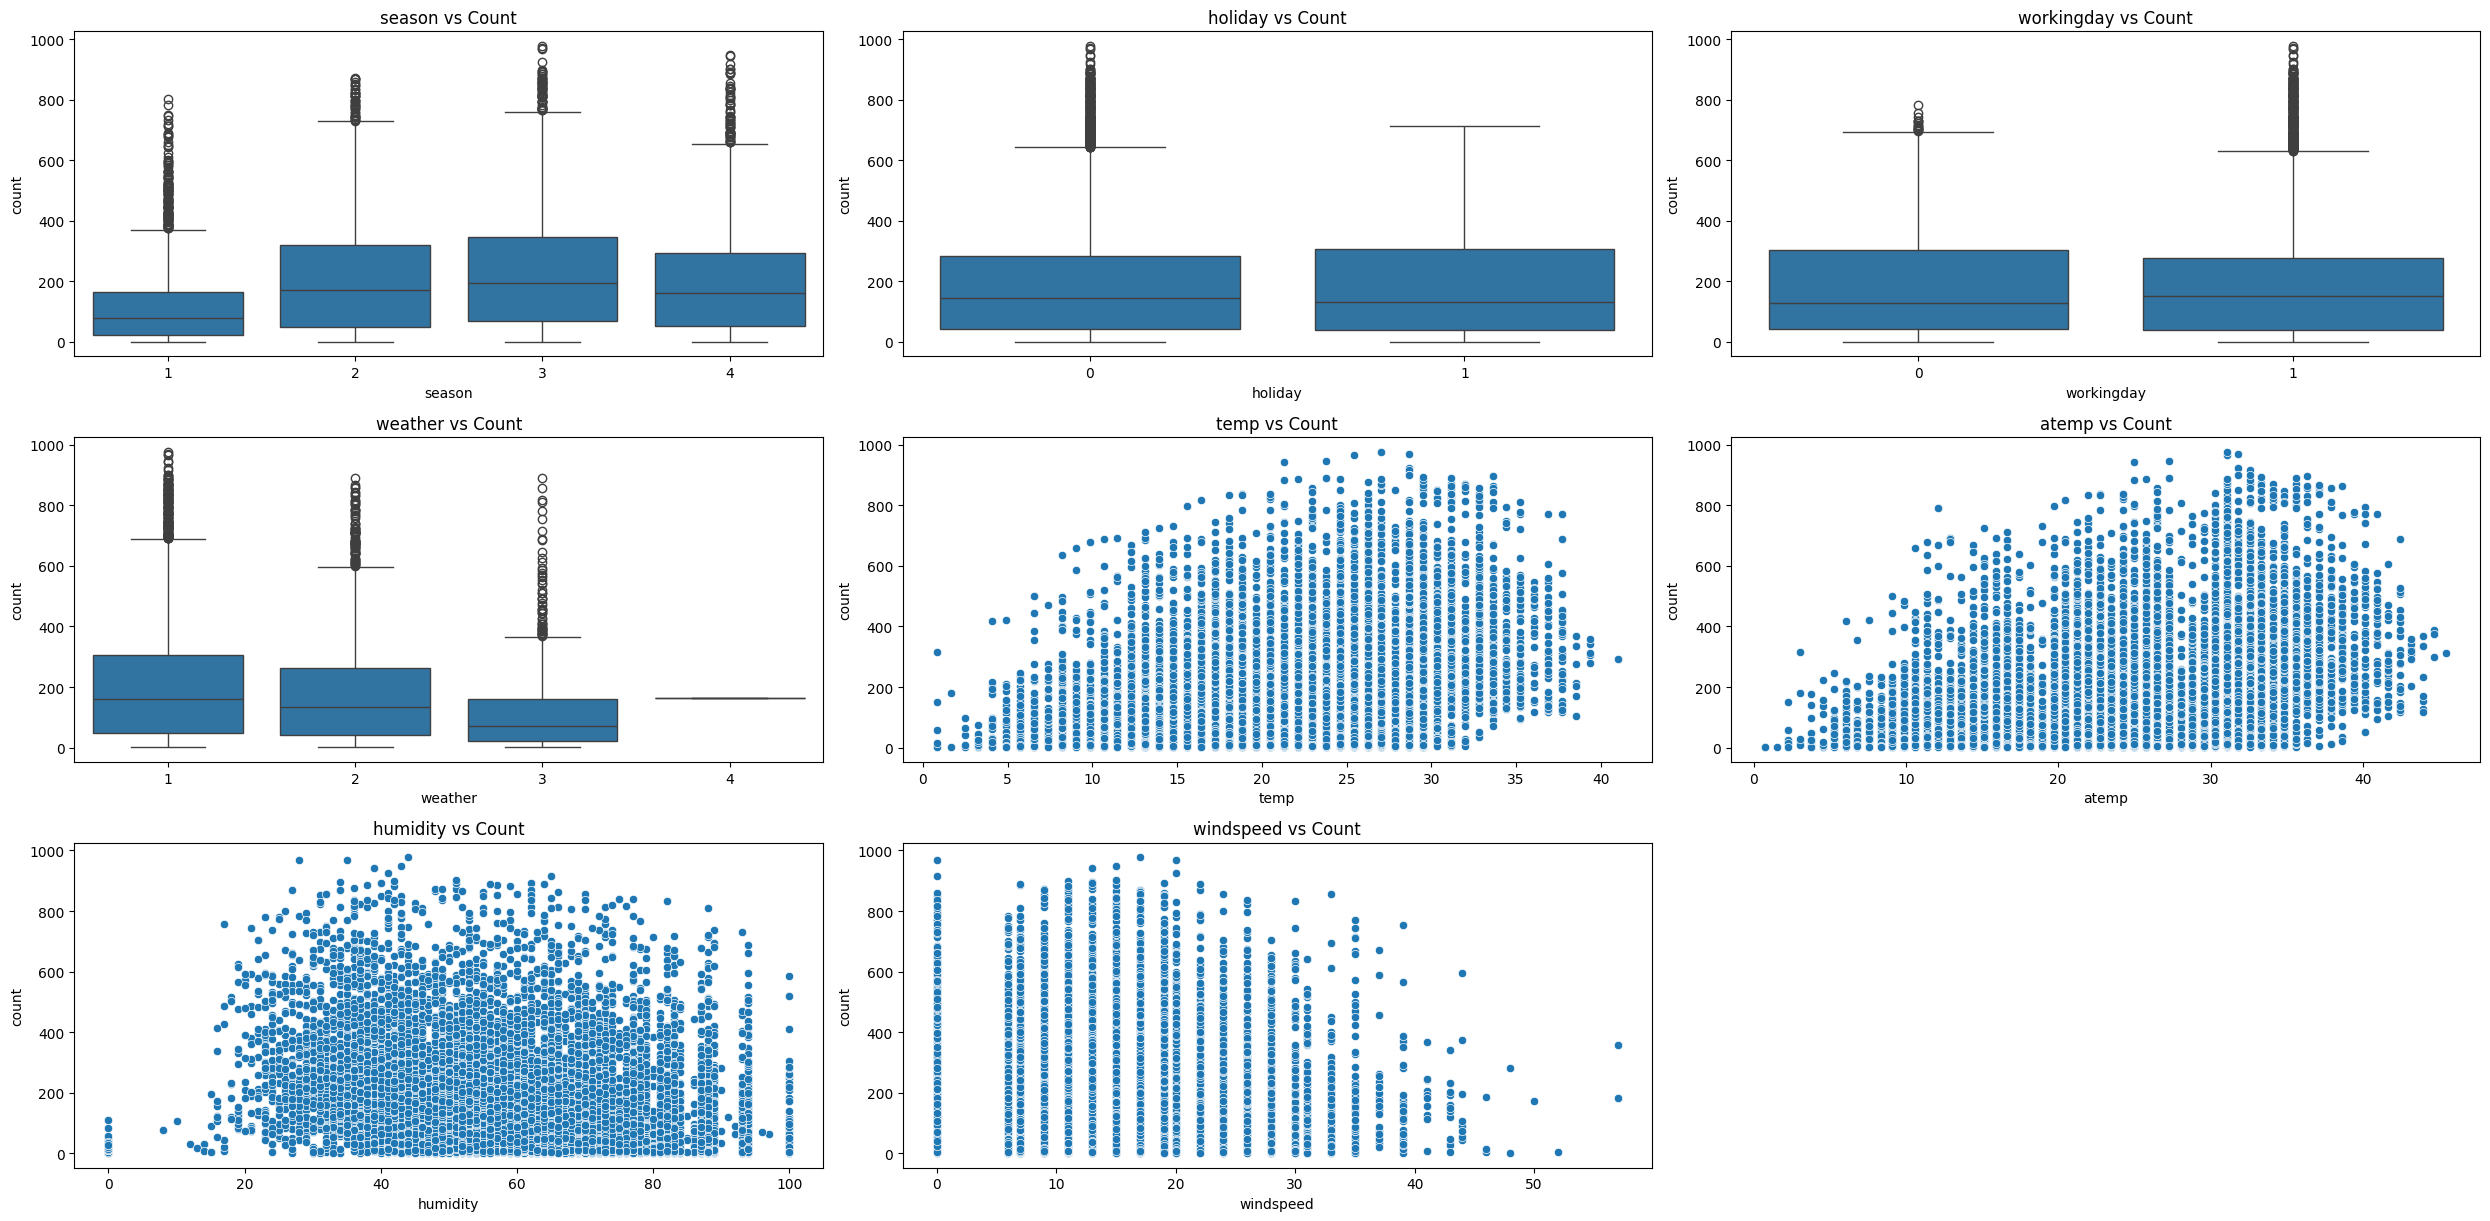

In [9]:
exclude_cols = ["count", "datetime", "casual", "registered"]

features = [col for col in train_data.columns if col not in exclude_cols]

plt.figure(figsize=(25, 20))

for i, col in enumerate(features, 1):
    plt.subplot(5, 3, i) # Changed from (4, 3, i) to (5, 3, i) to accommodate all features

    if train_data[col].dtype == 'object' or train_data[col].nunique() < 20:
        sns.boxplot(x=train_data[col], y=train_data["count"])
    else:
        sns.scatterplot(x=train_data[col], y=train_data["count"])

    plt.title(f"{col} vs Count")

plt.tight_layout()
plt.show()

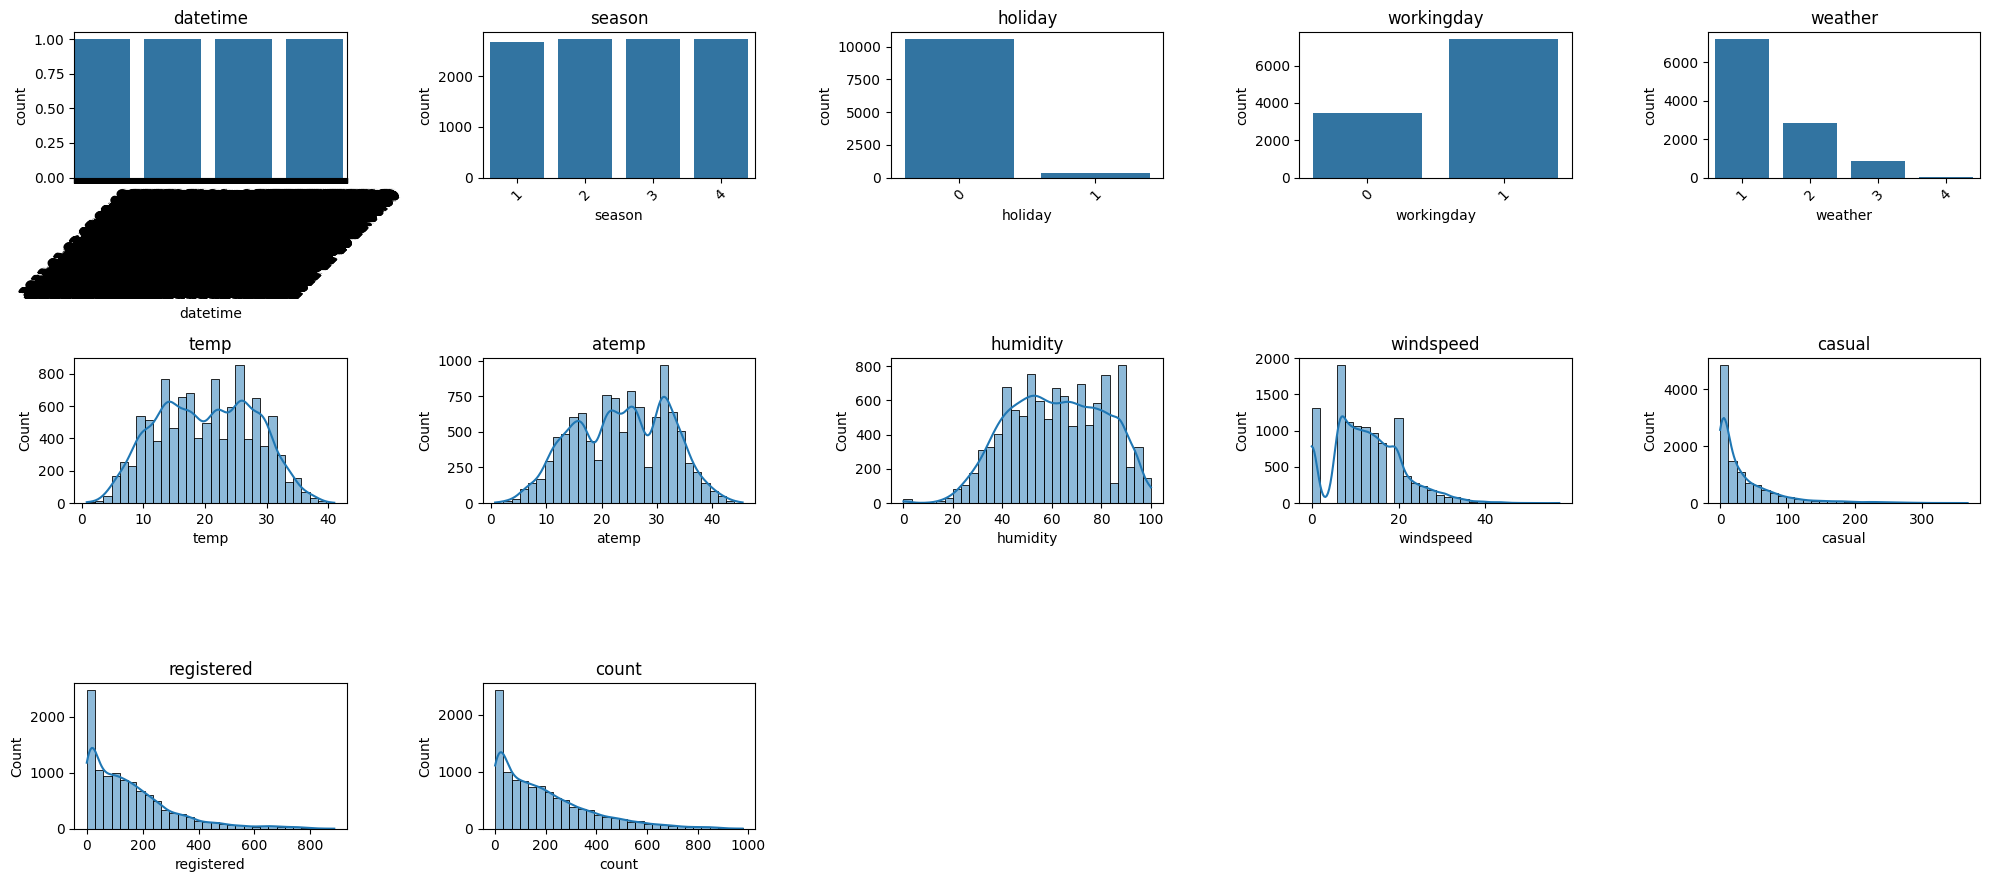

In [10]:
cols = train_data.columns

plt.figure(figsize=(20, 15))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 5, i)

    if train_data[col].dtype == "object" or train_data[col].nunique() < 20:
        sns.countplot(x=train_data[col])
        plt.xticks(rotation=45)
    else:
        sns.histplot(train_data[col], bins=30, kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

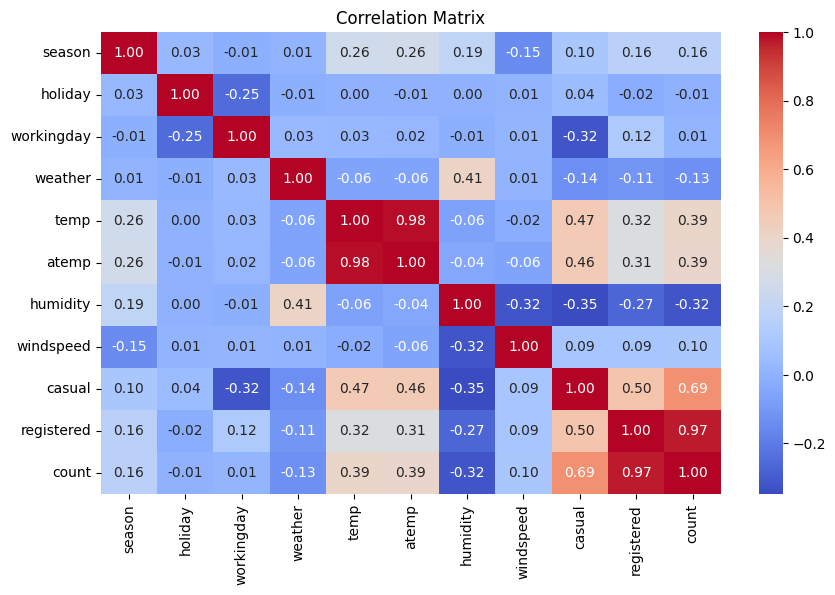

In [13]:
corr_matrix = train_data.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Linear Regression without feature engineering**

In [14]:
x = train_data.drop(columns=["count", "datetime", "casual", "registered"])
y = train_data["count"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

In [15]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_pred = np.maximum(0, y_pred)

rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("WITHOUT Cross Validation")
print("RMSLE:", rmsle)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

WITHOUT Cross Validation
RMSLE: 1.4305370124511005
MSE: 23851.28107450431
MAE: 114.6012420207375
R2: 0.27738578424756477


In [16]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)
mse_scorer = "neg_mean_squared_error"
mae_scorer = "neg_mean_absolute_error"
r2_scorer = "r2"


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


kf = KFold(n_splits=5, shuffle=True, random_state=42)


rmsle_scores = -cross_val_score(pipeline, x, y, cv=kf, scoring=rmsle_scorer)
mse_scores = -cross_val_score(pipeline, x, y, cv=kf, scoring=mse_scorer)
mae_scores = -cross_val_score(pipeline, x, y, cv=kf, scoring=mae_scorer)
r2_scores = cross_val_score(pipeline, x, y, cv=kf, scoring=r2_scorer)


print("WITH Cross Validation\n")

print("RMSLE Scores:", rmsle_scores)
print("Mean RMSLE:", rmsle_scores.mean())
print()

print("MSE Scores:", mse_scores)
print("Mean MSE:", mse_scores.mean())
print()

print("MAE Scores:", mae_scores)
print("Mean MAE:", mae_scores.mean())
print()

print("R2 Scores:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("STD R2:", r2_scores.std())

WITH Cross Validation

RMSLE Scores: [1.43053701 1.43782727 1.44819319 1.3750838  1.462378  ]
Mean RMSLE: 1.4308038544509631

MSE Scores: [23906.81469318 24165.70896088 23983.50235675 25590.77681766
 23821.1770291 ]
Mean MSE: 24293.5959715137

MAE Scores: [115.0413018  117.9795662  116.15118705 117.64716108 117.37140452]
Mean MAE: 116.83812413081303

R2 Scores: [0.2757033  0.23580832 0.27824778 0.2419581  0.2635773 ]
Mean R2: 0.25905896100689013
STD R2: 0.017312954383403314


**Linear Regression with feature engineering**

In [17]:
train_data["datetime"] = pd.to_datetime(train_data["datetime"])

train_data["hour"] = train_data["datetime"].dt.hour
train_data["day_of_week"] = train_data["datetime"].dt.weekday

train_data["is_weekend"] = train_data["day_of_week"].isin([5,6]).astype(int)
train_data["is_rush_hour"] = train_data["hour"].isin([7,8,17,18]).astype(int)

train_data = train_data.drop(columns=["atemp"])

train_data = pd.get_dummies(
    train_data,
    columns=["season", "weather"],
    drop_first=True
)

train_data["temp_humidity"] = train_data["temp"] * train_data["humidity"]
train_data["hour_sin"] = np.sin(2 * np.pi * train_data["hour"] / 24)
train_data["hour_cos"] = np.cos(2 * np.pi * train_data["hour"] / 24)
train_data["working_hour"] = train_data["workingday"] * train_data["hour"]

In [18]:
train_data

,datetime,holiday,workingday,temp,humidity,windspeed,casual,registered,count,hour,...,season_2,season_3,season_4,weather_2,weather_3,weather_4,temp_humidity,hour_sin,hour_cos,working_hour
0,2011-01-01 00:00:00,0,0,9.84,81,0.0000,3,13,16,0,...,False,False,False,False,False,False,797.04,0.000000,1.000000,0
1,2011-01-01 01:00:00,0,0,9.02,80,0.0000,8,32,40,1,...,False,False,False,False,False,False,721.60,0.258819,0.965926,0
2,2011-01-01 02:00:00,0,0,9.02,80,0.0000,5,27,32,2,...,False,False,False,False,False,False,721.60,0.500000,0.866025,0
3,2011-01-01 03:00:00,0,0,9.84,75,0.0000,3,10,13,3,...,False,False,False,False,False,False,738.00,0.707107,0.707107,0
4,2011-01-01 04:00:00,0,0,9.84,75,0.0000,0,1,1,4,...,False,False,False,False,False,False,738.00,0.866025,0.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,0,1,15.58,50,26.0027,7,329,336,19,...,False,False,True,False,False,False,779.00,-0.965926,0.258819,19
10882,2012-12-19 20:00:00,0,1,14.76,57,15.0013,10,231,241,20,...,False,False,True,False,False,False,841.32,-0.866025,0.500000,20
10883,2012-12-19 21:00:00,0,1,13.94,61,15.0013,4,164,168,21,...,False,False,True,False,False,False,850.34,-0.707107,0.707107,21
10884,2012-12-19 22:00:00,0,1,13.94,61,6.0032,12,117,129,22,...,False,False,True,False,False,False,850.34,-0.500000,0.866025,22


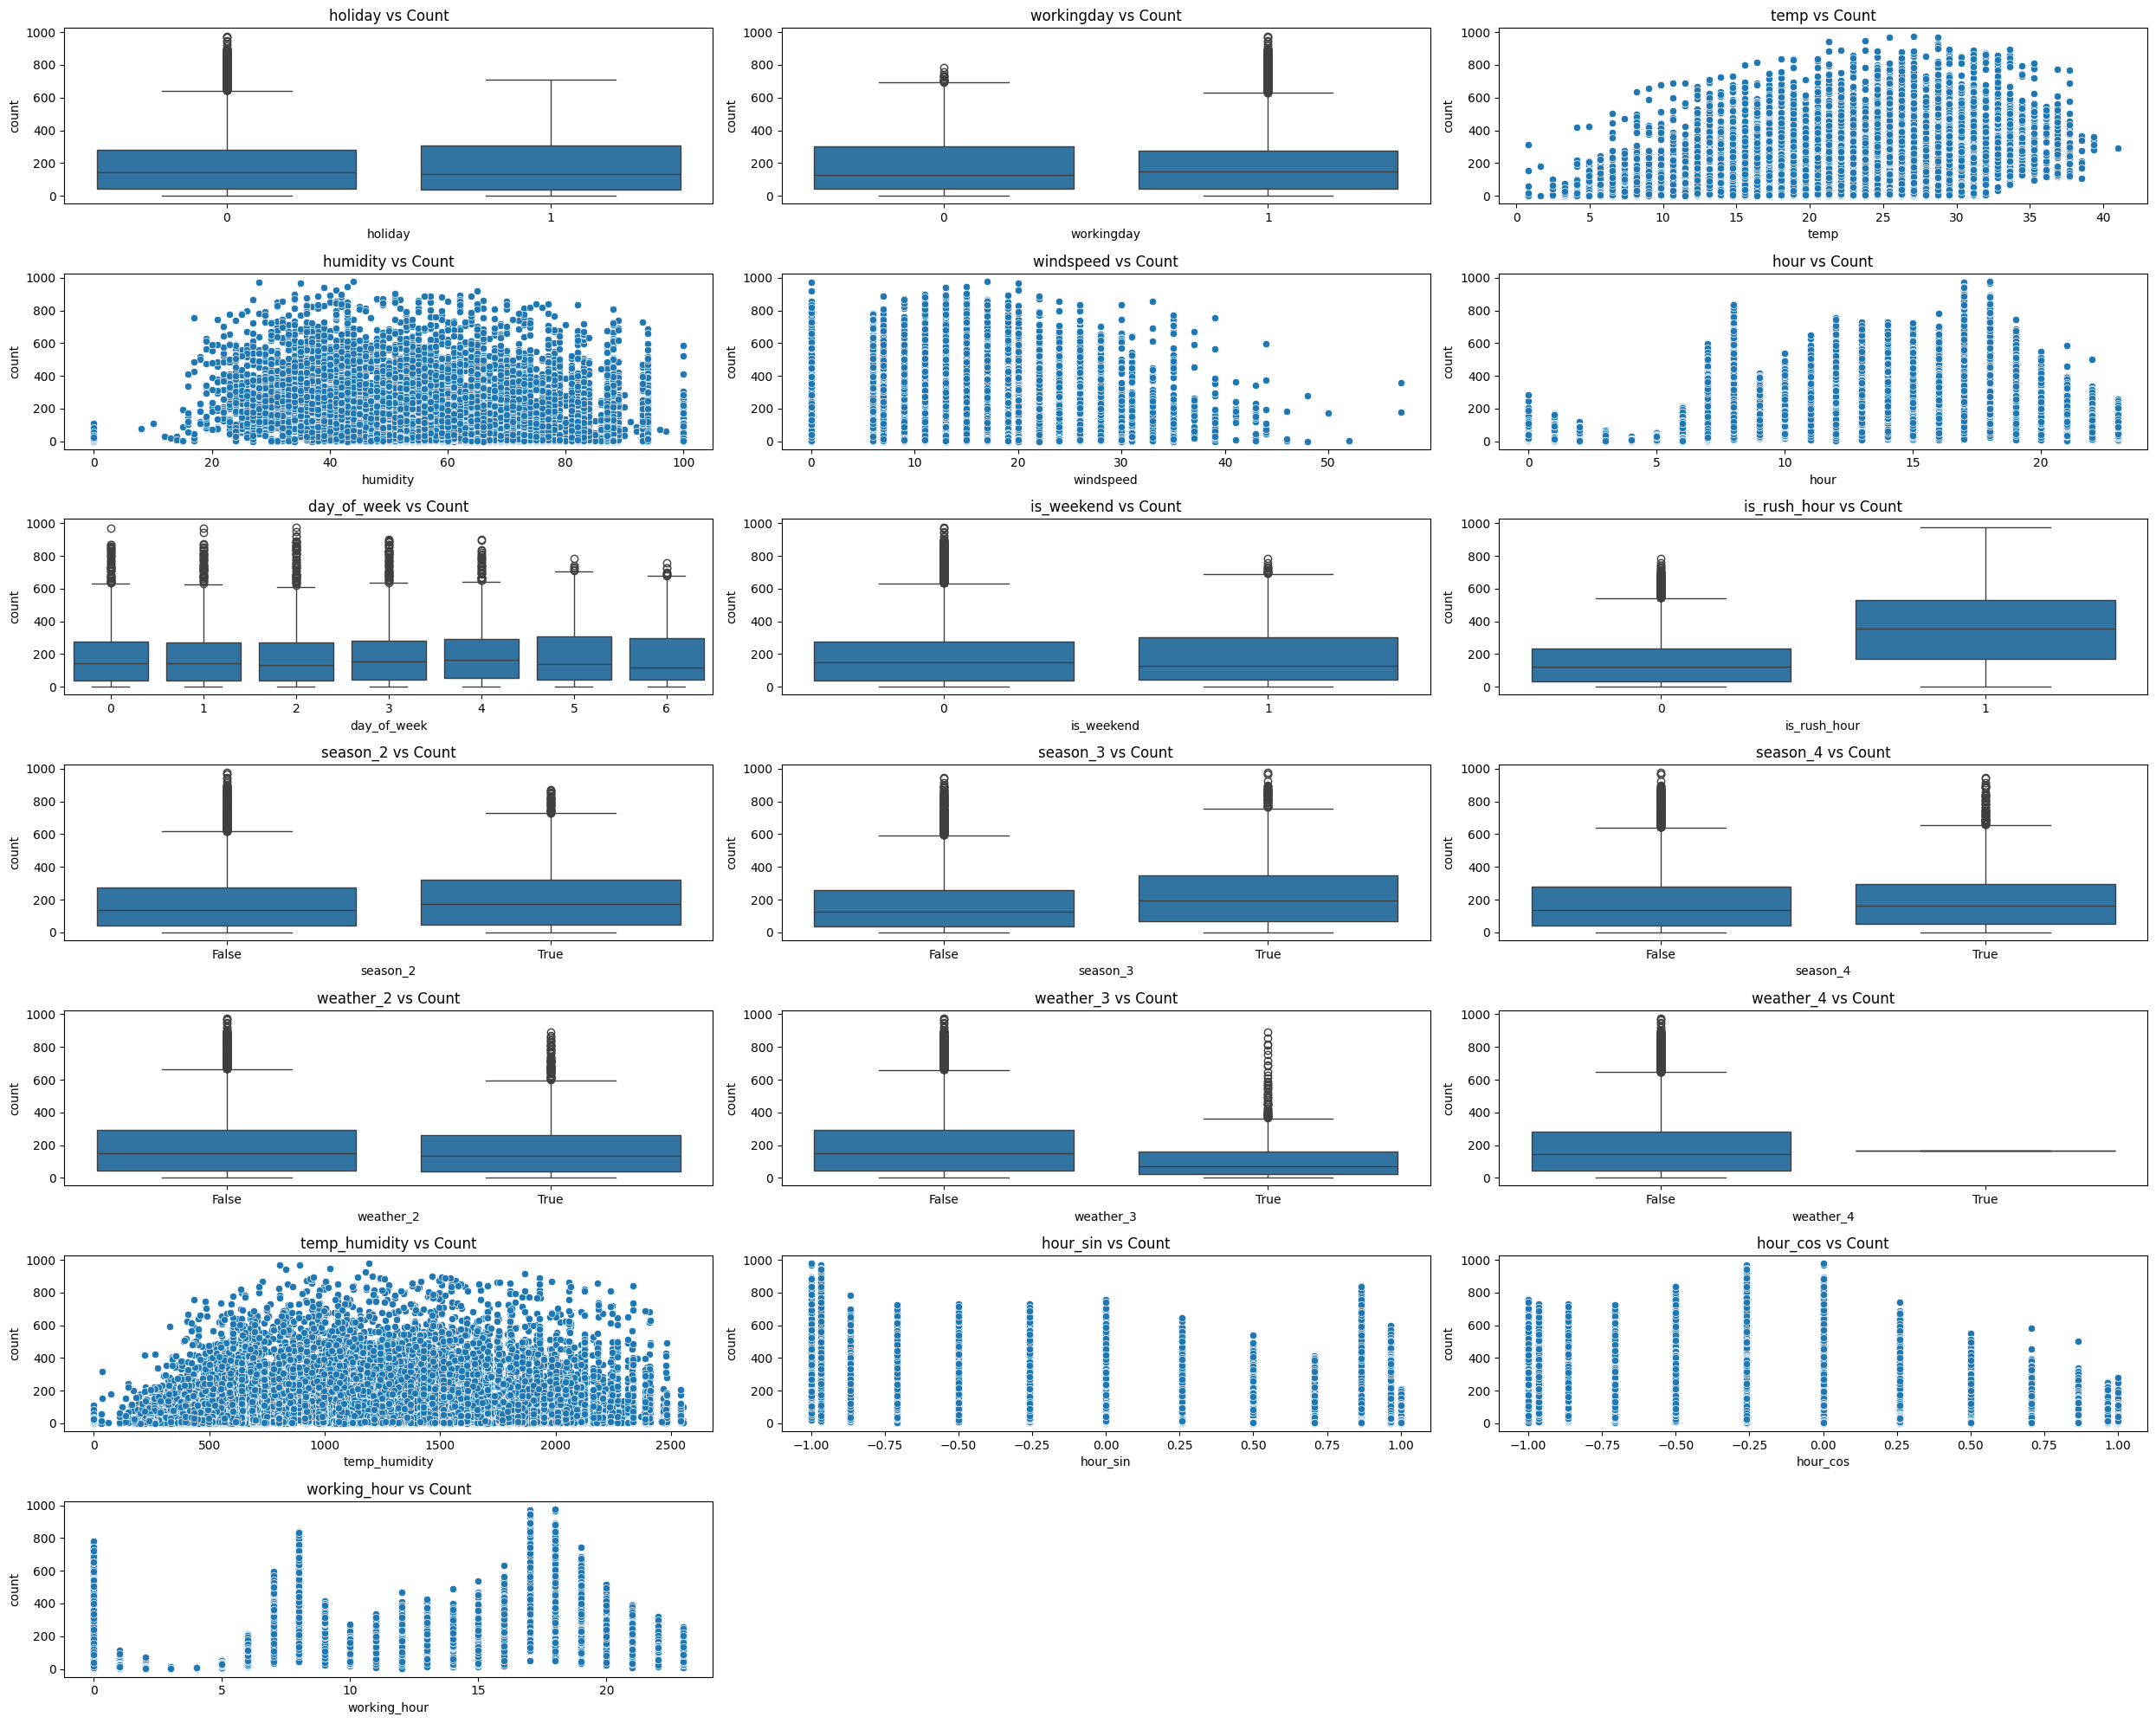

In [19]:
exclude_cols = ["count", "datetime", "casual", "registered"]

features = [col for col in train_data.columns if col not in exclude_cols]

plt.figure(figsize=(25, 20))

for i, col in enumerate(features, 1):
    plt.subplot(7, 3, i) # Changed from (6, 3, i) to (7, 3, i) to accommodate all features

    if train_data[col].dtype == 'object' or train_data[col].nunique() < 20:
        sns.boxplot(x=train_data[col], y=train_data["count"])
    else:
        sns.scatterplot(x=train_data[col], y=train_data["count"])

    plt.title(f"{col} vs Count")

plt.tight_layout()
plt.show()

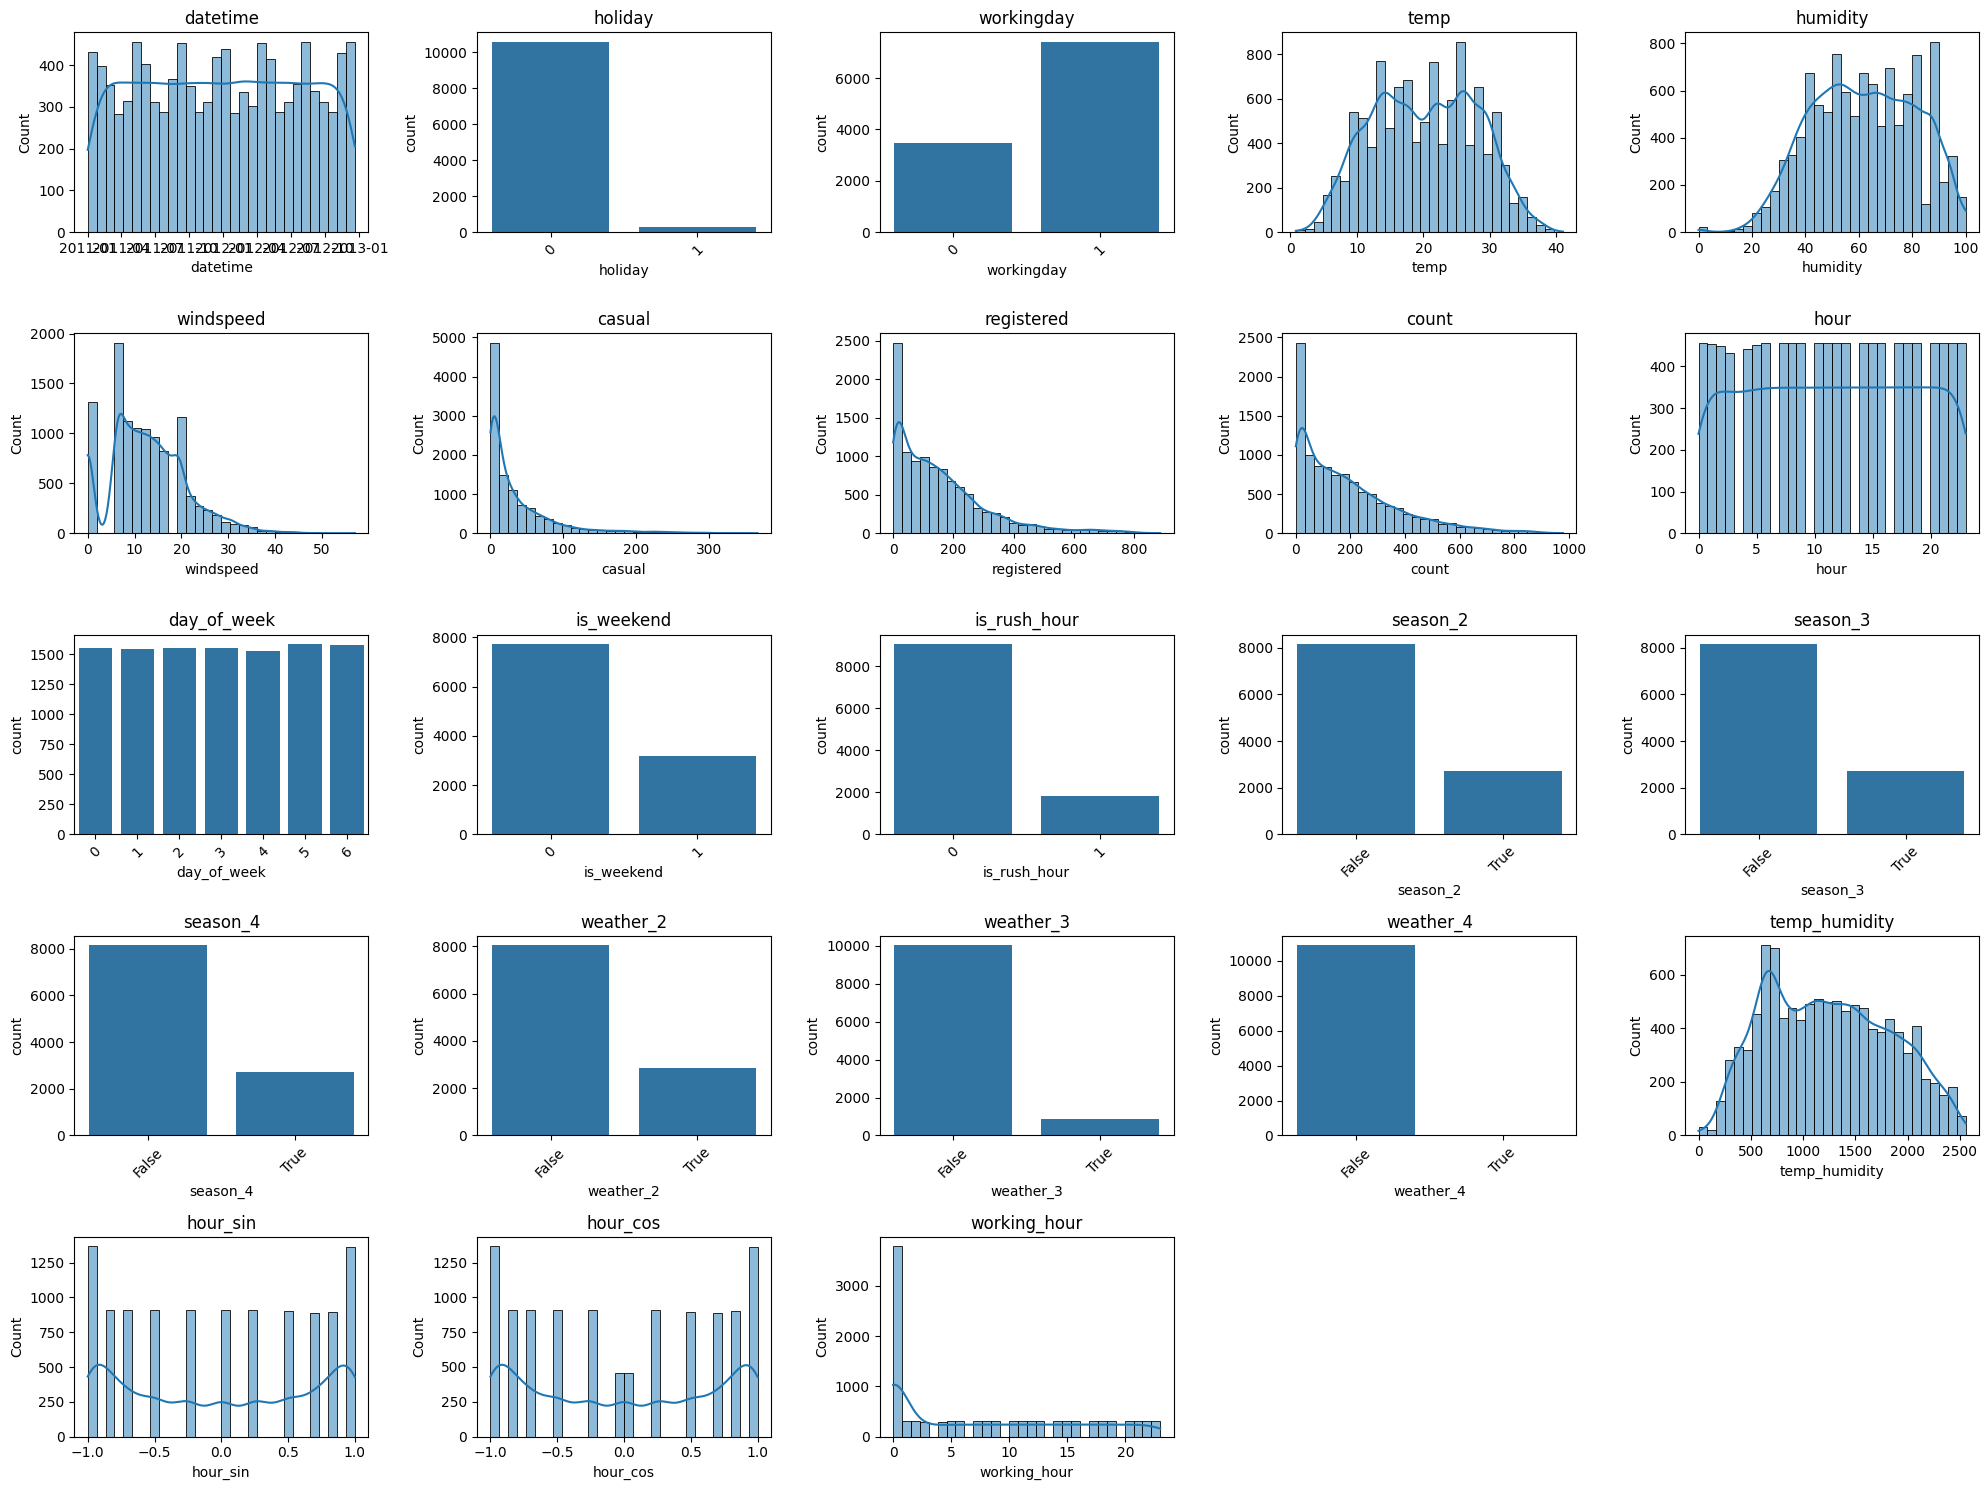

In [20]:
cols = train_data.columns

plt.figure(figsize=(20, 15))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 5, i)

    if train_data[col].dtype == "object" or train_data[col].nunique() < 20:
        sns.countplot(x=train_data[col])
        plt.xticks(rotation=45)
    else:
        sns.histplot(train_data[col], bins=30, kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

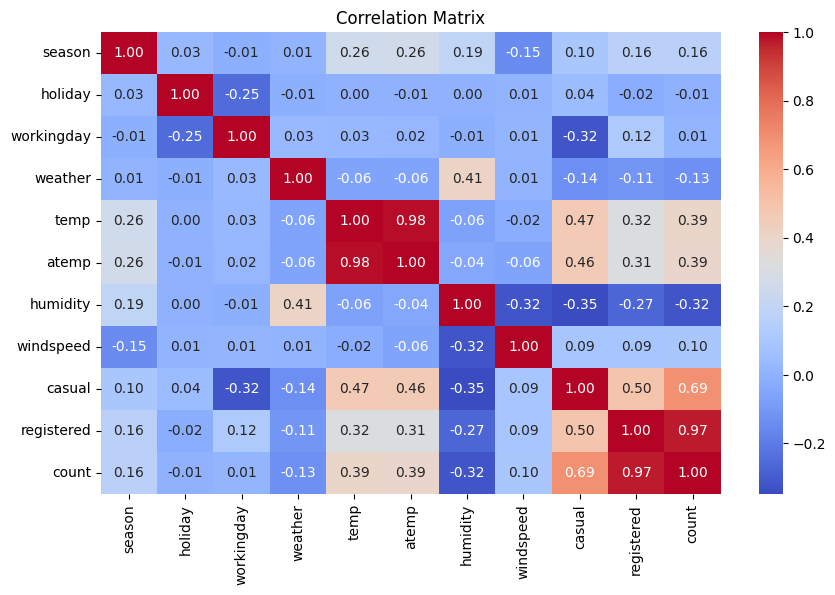

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [22]:
x = train_data.drop(columns=["count", "datetime", "casual", "registered"])
y = np.log1p(train_data["count"])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

In [23]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred_log = model.predict(x_test_scaled)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

y_pred = np.maximum(0, y_pred)

rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred))
mse = mean_squared_error(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("WITHOUT Cross Validation")
print("RMSLE:", rmsle)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

WITHOUT Cross Validation
RMSLE: 0.780184791828281
MSE: 17281.97611332651
MAE: 86.67174916320216
R2: 0.47641380029968516


In [24]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmsle_list = []
mse_list = []
mae_list = []
r2_list = []

for train_idx, test_idx in kf.split(x):
    X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train_log, y_test_log = y.iloc[train_idx], y.iloc[test_idx]


    pipeline.fit(X_train, y_train_log)


    y_pred_log = pipeline.predict(X_test)


    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test_log)

    y_pred = np.maximum(0, y_pred)

    rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred))
    mse = mean_squared_error(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    r2 = r2_score(y_test_original, y_pred)

    rmsle_list.append(rmsle)
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)

print("WITH Cross Validation (ORIGINAL SCALE)\n")

print("RMSLE:", rmsle_list)
print("Mean RMSLE:", np.mean(rmsle_list))
print("STD RMSLE:", np.std(rmsle_list))
print()

print("Mean MSE:", np.mean(mse_list))
print("Mean MAE:", np.mean(mae_list))
print()

print("Mean R2:", np.mean(r2_list))
print("STD R2:", np.std(r2_list))

WITH Cross Validation (ORIGINAL SCALE)

RMSLE: [np.float64(0.780184791828281), np.float64(0.7792887845728942), np.float64(0.7843041912814731), np.float64(0.7797049544112287), np.float64(0.7788712732204388)]
Mean RMSLE: 0.7804707990628632
STD RMSLE: 0.001965647742880178

Mean MSE: 18022.573201681604
Mean MAE: 87.72112459147587

Mean R2: 0.4501959112205771
STD R2: 0.029093550176494457


**Ohter Models With the final training**

In [25]:
train_data

,datetime,holiday,workingday,temp,humidity,windspeed,casual,registered,count,hour,...,season_2,season_3,season_4,weather_2,weather_3,weather_4,temp_humidity,hour_sin,hour_cos,working_hour
0,2011-01-01 00:00:00,0,0,9.84,81,0.0000,3,13,16,0,...,False,False,False,False,False,False,797.04,0.000000,1.000000,0
1,2011-01-01 01:00:00,0,0,9.02,80,0.0000,8,32,40,1,...,False,False,False,False,False,False,721.60,0.258819,0.965926,0
2,2011-01-01 02:00:00,0,0,9.02,80,0.0000,5,27,32,2,...,False,False,False,False,False,False,721.60,0.500000,0.866025,0
3,2011-01-01 03:00:00,0,0,9.84,75,0.0000,3,10,13,3,...,False,False,False,False,False,False,738.00,0.707107,0.707107,0
4,2011-01-01 04:00:00,0,0,9.84,75,0.0000,0,1,1,4,...,False,False,False,False,False,False,738.00,0.866025,0.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,0,1,15.58,50,26.0027,7,329,336,19,...,False,False,True,False,False,False,779.00,-0.965926,0.258819,19
10882,2012-12-19 20:00:00,0,1,14.76,57,15.0013,10,231,241,20,...,False,False,True,False,False,False,841.32,-0.866025,0.500000,20
10883,2012-12-19 21:00:00,0,1,13.94,61,15.0013,4,164,168,21,...,False,False,True,False,False,False,850.34,-0.707107,0.707107,21
10884,2012-12-19 22:00:00,0,1,13.94,61,6.0032,12,117,129,22,...,False,False,True,False,False,False,850.34,-0.500000,0.866025,22


In [26]:
x_full = train_data.drop(columns=["count", "datetime", "casual", "registered"])
y_full = np.log1p(train_data["count"])

test_datetime = test_data["datetime"]

test_data["datetime"] = pd.to_datetime(test_data["datetime"])

test_data["hour"] = test_data["datetime"].dt.hour
test_data["day_of_week"] = test_data["datetime"].dt.weekday

test_data["is_weekend"] = test_data["day_of_week"].isin([5, 6]).astype(int)
test_data["is_rush_hour"] = test_data["hour"].isin([7, 8, 17, 18]).astype(int)

test_data["hour_sin"] = np.sin(2 * np.pi * test_data["hour"] / 24)
test_data["hour_cos"] = np.cos(2 * np.pi * test_data["hour"] / 24)
test_data["working_hour"] = test_data["workingday"] * test_data["hour"]

test_data["temp_humidity"] = test_data["temp"] * test_data["humidity"]

test_data = test_data.drop(columns=["datetime", "atemp"])

test_data = pd.get_dummies(
    test_data,
    columns=["season", "weather"],
    drop_first=True
)

In [27]:
test_data

,holiday,workingday,temp,humidity,windspeed,hour,day_of_week,is_weekend,is_rush_hour,hour_sin,hour_cos,working_hour,temp_humidity,season_2,season_3,season_4,weather_2,weather_3,weather_4
0,0,1,10.66,56,26.0027,0,3,0,0,0.000000,1.000000,0,596.96,False,False,False,False,False,False
1,0,1,10.66,56,0.0000,1,3,0,0,0.258819,0.965926,1,596.96,False,False,False,False,False,False
2,0,1,10.66,56,0.0000,2,3,0,0,0.500000,0.866025,2,596.96,False,False,False,False,False,False
3,0,1,10.66,56,11.0014,3,3,0,0,0.707107,0.707107,3,596.96,False,False,False,False,False,False
4,0,1,10.66,56,11.0014,4,3,0,0,0.866025,0.500000,4,596.96,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,0,1,10.66,60,11.0014,19,0,0,0,-0.965926,0.258819,19,639.60,False,False,False,True,False,False
6489,0,1,10.66,60,11.0014,20,0,0,0,-0.866025,0.500000,20,639.60,False,False,False,True,False,False
6490,0,1,10.66,60,11.0014,21,0,0,0,-0.707107,0.707107,21,639.60,False,False,False,False,False,False
6491,0,1,10.66,56,8.9981,22,0,0,0,-0.500000,0.866025,22,596.96,False,False,False,False,False,False


In [28]:
scaler = StandardScaler()
x_full_scaled = scaler.fit_transform(x_full)

final_model = LinearRegression()
final_model.fit(x_full_scaled, y_full)

LinearRegression()

In [29]:
test_data = test_data.reindex(columns=x_full.columns, fill_value=0)

test_scaled = scaler.transform(test_data)

test_pred_log = final_model.predict(test_scaled)

test_pred = np.expm1(test_pred_log)
test_pred = np.maximum(0, test_pred)

submission = pd.DataFrame({
    "datetime": test_datetime,
    "count": test_pred
})

submission.to_csv("submission_1.csv", index=False)

In [30]:
test_data = test_data.reindex(columns=x_full.columns, fill_value=0)

final_rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(x_full, y_full)

test_pred = final_rf_model.predict(test_data)
test_pred = np.maximum(0, test_pred)

submission_2 = pd.DataFrame({
    "datetime": test_datetime,
    "count": test_pred
})

submission_2.to_csv("submission_2.csv", index=False)

In [31]:
print('RMSLE for the test_data(kaggle) using LinearRegression: 0.78')
print('RMSLE for the test_data(kaggle) using RandomForest: 0.47')

RMSLE for the test_data(kaggle) using LinearRegression: 0.78
RMSLE for the test_data(kaggle) using RandomForest: 0.47
